**Logistic Regression Basline with TF-IDF Features**

Author: Umme-Yusrah Sumtally

Experiments:
  1. Overall evaluation (train on all varieties, test on all)
  2. Per-variety evaluation (test split per variety)

**Imports**

In [ ]:
from src.data_loader import get_BESSTIE_splits
from src.lr_feature_extraction import tfidf_features
from models.logistic_regression_class_helper import extract_labels, calculate_metrics, SeparateLR

**Loading data**

In [ ]:
df_all, y_train, df_validation, y_test = get_BESSTIE_splits()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

**Extract TF-IDF Features**

In [ ]:
train_features, val_features,test_features, vectorizer = tfidf_features(
    y_train, df_validation, y_test,
    text_column='text',
    max_features=13500,
    save_path="./models/tfidf"
)

**Experiment 1: Overall Evaluation**

Train on all varieties,

validate and tune thresholds,

evaluation on test set comprising of all 3 varieties

In [ ]:
model = SeparateLR()
model.train_SeparateLR( train_features, y_train,X_validation=val_features, y_validation_df=df_validation
)

In [ ]:
print("\n Validation Results ")
validation_results = model.SeparateLR_evaluation(val_features, df_validation)

print(f"\n SARCASM DETECTION:")
print(f"   Macro F1-Score: {validation_results['Sarcasm']['F1_Macro']:.4f}")

print(f"\n SENTIMENT ANALYSIS:")
print(f"   Macro F1-Score: {validation_results['Sentiment']['F1_Macro']:.4f}")

print("\n Final Test Results on all varieties combined ")
test_results = model.SeparateLR_evaluation(test_features, y_test)

print(f"\n SARCASM DETECTION:")
print(f"   Accuracy:       {test_results['Sarcasm']['Accuracy']:.4f}")
print(f"   Precision:      {test_results['Sarcasm']['Precision']:.4f}")
print(f"   Recall:         {test_results['Sarcasm']['Recall']:.4f}")
print(f"   F1-Score:       {test_results['Sarcasm']['F1']:.4f}")
print(f"   Macro F1-Score: {test_results['Sarcasm']['F1_Macro']:.4f}")

print(f"\n SENTIMENT ANALYSIS:")
print(f"   Accuracy:       {test_results['Sentiment']['Accuracy']:.4f}")
print(f"   Precision:      {test_results['Sentiment']['Precision']:.4f}")
print(f"   Recall:         {test_results['Sentiment']['Recall']:.4f}")
print(f"   F1-Score:       {test_results['Sentiment']['F1']:.4f}")
print(f"   Macro F1-Score: {test_results['Sentiment']['F1_Macro']:.4f}")

model.save_SeparateLR_models("./models")


 Validation Results 

 SARCASM DETECTION:
   Macro F1-Score: 0.6658

 SENTIMENT ANALYSIS:
   Macro F1-Score: 0.8618

 Final Test Results on all varieties combined 

 SARCASM DETECTION:
   Accuracy:       0.7655
   Precision:      0.3128
   Recall:         0.5672
   F1-Score:       0.4033
   Macro F1-Score: 0.6287

 SENTIMENT ANALYSIS:
   Accuracy:       0.8319
   Precision:      0.8870
   Recall:         0.7514
   F1-Score:       0.8136
   Macro F1-Score: 0.8303
 Models and thresholds saved


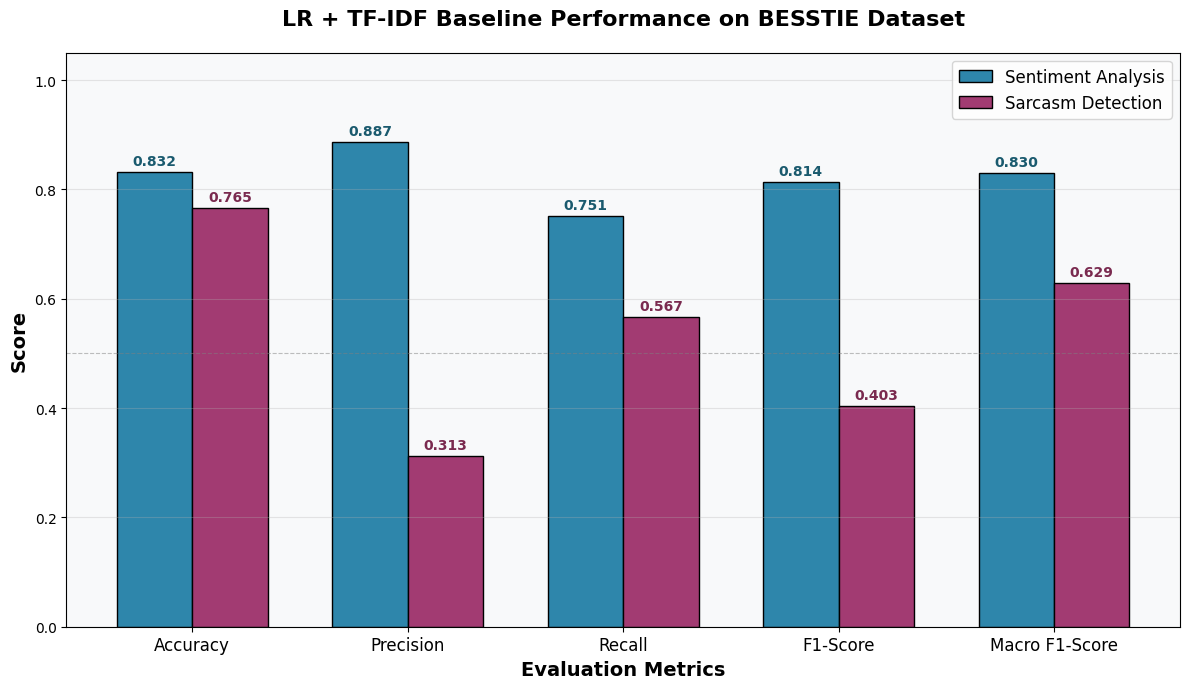

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Macro F1-Score']

sentiment_values = [
    test_results['Sentiment']['Accuracy'],
    test_results['Sentiment']['Precision'],
    test_results['Sentiment']['Recall'],
    test_results['Sentiment']['F1'],
    test_results['Sentiment']['F1_Macro']
]

sarcasm_values = [
    test_results['Sarcasm']['Accuracy'],  test_results['Sarcasm']['Precision'],
    test_results['Sarcasm']['Recall'], test_results['Sarcasm']['F1'],
    test_results['Sarcasm']['F1_Macro']
]


x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, sentiment_values, width,
               label='Sentiment Analysis',
               color='#2E86AB',
               edgecolor='black',
               linewidth=1)

bars2 = ax.bar(x + width/2, sarcasm_values, width,
               label='Sarcasm Detection',  color='#A23B72', edgecolor='black',  linewidth=1)


ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_title('LR + TF-IDF Baseline Performance on BESSTIE Dataset', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(loc='upper right', fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold',  color='#1a5a6e')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color='#7a2a4f')

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('baseline_grouped_bar.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


Trained on all -- tested on all varieties Experiment - classification report

In [ ]:
from sklearn.metrics import classification_report

test_predictions = model.label_prediction_SeparateLR(test_features)
true_sarc_lbls, true_sent = extract_labels(y_test)

print(" Per-Class Report: SARCASM ")
print(classification_report(
    true_sarc_lbls,
    test_predictions['Sarcasm'],
    target_names=['Non-Sarcastic', 'Sarcastic']
))

print("\n Per-Class Report: SENTIMENT ")
print(classification_report(
    true_sent,test_predictions['Sentiment'],target_names=['Negative', 'Positive']
))

 Per-Class Report: SARCASM 
               precision    recall  f1-score   support

Non-Sarcastic       0.92      0.80      0.85      1878
    Sarcastic       0.31      0.57      0.40       305

     accuracy                           0.77      2183
    macro avg       0.62      0.68      0.63      2183
 weighted avg       0.83      0.77      0.79      2183


 Per-Class Report: SENTIMENT 
              precision    recall  f1-score   support

    Negative       0.79      0.91      0.85      1117
    Positive       0.89      0.75      0.81      1066

    accuracy                           0.83      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.84      0.83      0.83      2183



**Experiment 2: PER-VARIETY Evaluation**

Using same trained model as experiment

Evaluate on per variety test sets

In [ ]:
import numpy as np

english_varieties = ['en-AU', 'en-IN', 'en-UK']
per_variety_results={}

for variety in english_varieties:
    en_var_mask =  (y_test['variety'] == variety).values
    X_test_variety =test_features[en_var_mask]
    y_test_var=y_test[en_var_mask]

    per_variety_results[variety] = model.SeparateLR_evaluation(X_test_variety,  y_test_var)


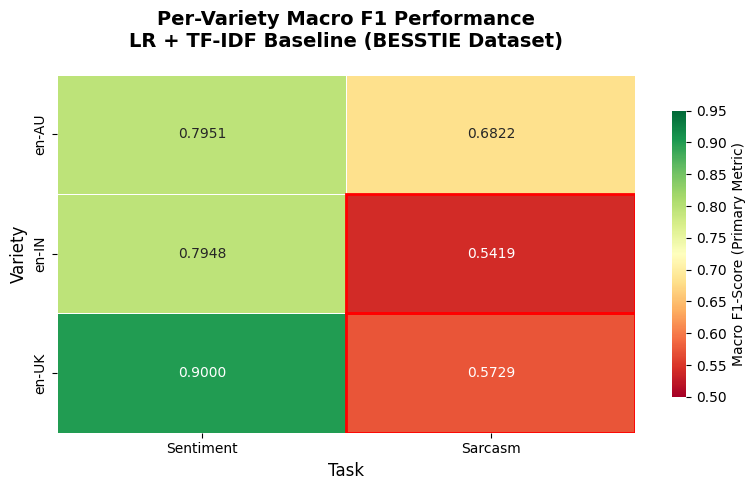

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'F1_Macro']
macro_f1_data = {
    'en-AU': {'Sentiment': per_variety_results['en-AU']['Sentiment']['F1_Macro'], 'Sarcasm': per_variety_results['en-AU']['Sarcasm']['F1_Macro']},
    'en-IN': {'Sentiment': per_variety_results['en-IN']['Sentiment']['F1_Macro'], 'Sarcasm': per_variety_results['en-IN']['Sarcasm']['F1_Macro']},
    'en-UK': {'Sentiment': per_variety_results['en-UK']['Sentiment']['F1_Macro'],
              'Sarcasm': per_variety_results['en-UK']['Sarcasm']['F1_Macro']}
}

macro_dataframe = pd.DataFrame(macro_f1_data).T
ure, plot_ax = plt.subplots(figsize=(8, 5))
sns.heatmap(macro_dataframe, annot=True, fmt='.4f', cmap='RdYlGn',  vmin=0.5, vmax=0.95, linewidths=0.5, ax=plot_ax,
            cbar_kws={'label': 'Macro F1-Score (Primary Metric)', 'shrink': 0.8})

for i, variety in enumerate(english_varieties):
    for j, task in enumerate(['Sentiment', 'Sarcasm']):
        if macro_dataframe.iloc[i, j] < 0.6:
            plot_ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', linewidth=2))

plot_ax.set_title('Per-Variety Macro F1 Performance\nLR + TF-IDF Baseline (BESSTIE Dataset)',
             fontsize=14, fontweight='bold', pad=20)
plot_ax.set_xlabel('Task', fontsize=12)
plot_ax.set_ylabel('Variety', fontsize=12)

plt.tight_layout()
plt.savefig('per_variety_macro_f1_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


per variety per class classification report

In [ ]:
for variety in ['en-AU', 'en-IN', 'en-UK']:
    mask = (y_test['variety'] == variety).values
    X_test_var=test_features[mask]
    df_test_var= y_test[mask]

    true_sarc, true_sent = extract_labels(df_test_var)
    preds_var = model.label_prediction_SeparateLR(X_test_var)

    print(f"---------VARIETY: {variety}----------")
    print("SARCASM:")
    print(classification_report(
        true_sarc, preds_var['Sarcasm'],
        target_names=['Non-Sarcastic', 'Sarcastic'],
        zero_division=0
    ))

    print("SENTIMENT:")
    print(classification_report( true_sent, preds_var['Sentiment'], target_names=['Negative', 'Positive'],  zero_division=0
    ))

---------VARIETY: en-AU----------
SARCASM:
               precision    recall  f1-score   support

Non-Sarcastic       0.83      0.76      0.80       471
    Sarcastic       0.52      0.62      0.57       196

     accuracy                           0.72       667
    macro avg       0.68      0.69      0.68       667
 weighted avg       0.74      0.72      0.73       667

SENTIMENT:
              precision    recall  f1-score   support

    Negative       0.74      0.95      0.83       347
    Positive       0.92      0.64      0.76       320

    accuracy                           0.80       667
   macro avg       0.83      0.80      0.80       667
weighted avg       0.83      0.80      0.80       667

---------VARIETY: en-IN----------
SARCASM:
               precision    recall  f1-score   support

Non-Sarcastic       0.95      0.80      0.87       760
    Sarcastic       0.14      0.45      0.21        56

     accuracy                           0.78       816
    macro avg       0